# Last-Call 🕛
### The market makes its money in four days a month — so why can't you trade it?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Still alive?: Faded](https://img.shields.io/badge/Still_alive%3F-Faded-8b949e?style=flat-square)

For decades, stock returns have piled up in a tiny window around month-end — the last trading day plus the first three of the next. It's one of the most replicated facts in finance. The twist: a strategy that owns the market *only* in that window — even with its idle cash earning Treasury-bill interest — **loses to just buying and holding**, and the effect has quietly died since 2008.

> 📓 **Plain-language layer.** The t-stats and the decay are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (last_call/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from last_call import data, strategy as st
gspc = data.fetch_prices("^GSPC", start_year=1950)   # effect (price-only index)
spy  = data.fetch_prices("SPY", start_year=1993)     # tradable (total return)
rf   = data.fetch_tbill().reindex(spy.index).ffill().fillna(0.0)  # the cash leg (^IRX/252)
d = st.tom_vs_rest(gspc)


## The answer first 🎯

| The fact | The catch |
|---|---|
| Turn-of-month days earn **~6×** an ordinary day | But they're only **19%** of days — own just them and you compound *less*. |
| "11 basis points a day!" | The window-only book makes **5.5%/yr** (cash parked in T-bills) vs buy-and-hold's **10.8%**. |
| "A robust 70-year anomaly" | Since 2008 the window earns what any other day earns — and that fade is itself statistically significant. |

## 1 · The claim

Equity returns concentrate at the **turn of the month** (Lakonishok & Smidt 1988; McConnell & Xu 2008): be in the market for the last day and the first three of each month, and you capture almost all of its drift in a fraction of the days.

## 2 · So what?

If nearly all the return happens in a predictable four-day window, you could be in cash 80% of the time, dodge most of the risk, and keep the return. That's the dream the effect sells. Does the arithmetic actually work?

## 3 · How would we even know?

Mark the turn-of-the-month days, compare their average return to every other day (with a t-stat), then **build the tradable rule** — long exactly the window (it's set by the calendar, so you know it in advance), T-bills otherwise — and race it against simply holding SPY, after costs, comparing like with like.

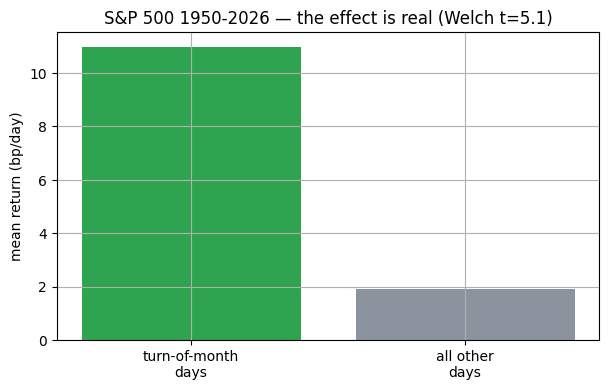

In [2]:
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['turn-of-month\ndays','all other\ndays'],[d['tom_bp'],d['rest_bp']],color=['#2ea44f','#8b949e'])
ax.set_ylabel('mean return (bp/day)'); ax.set_title(f"S&P 500 1950-2026 — the effect is real (Welch t={d['welch_t']:.1f})"); plt.show()

## 4 · The teardown

The per-day gap is huge and real. Now watch what happens when you actually trade it — with the fairest possible setup: the book holds the exact window and its cash earns the T-bill.

,cagr,sharpe,max_drawdown,time in market
"TOM-only (2bp, cash at T-bill)",5.0%,0.66,-18%,19%
Buy & hold SPY,10.8%,0.64,-55%,100%


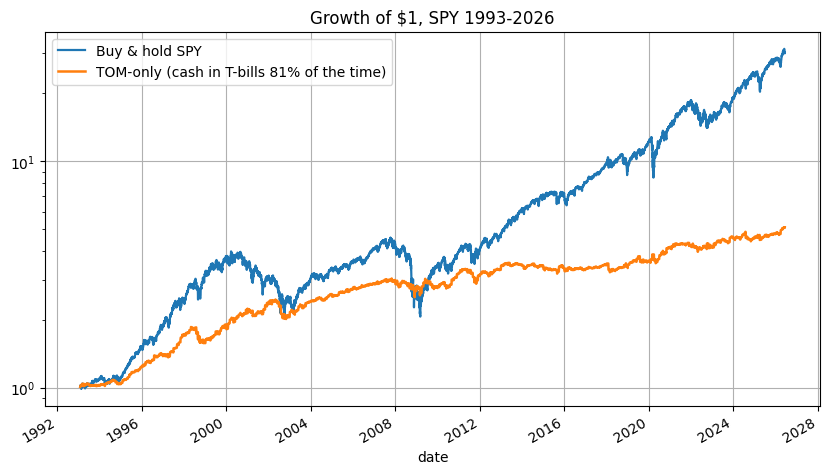

In [3]:
book = st.tom_returns(spy, 2.0, rf=rf)
rows={'TOM-only (2bp, cash at T-bill)': st.summary(book), 'Buy & hold SPY': st.summary(st.buy_hold(spy))}
t=pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']]
t['time in market']=[st.tom_mask(spy.index).mean(),1.0]
display(t.style.format({'cagr':'{:.1%}','sharpe':'{:.2f}','max_drawdown':'{:.0%}','time in market':'{:.0%}'}))
eqT=(1+book).cumprod(); eqB=(1+st.buy_hold(spy)).cumprod()
ax=eqB.plot(label='Buy & hold SPY',lw=1.6); eqT.plot(ax=ax,label='TOM-only (cash in T-bills 81% of the time)',lw=1.8)
ax.set_yscale('log'); ax.set_title('Growth of $1, SPY 1993-2026'); ax.legend(); plt.show()

**Read it plainly.** A higher return *per day* isn't a higher return — out of the market four-fifths of the time, the window book ends far behind even with its cash earning interest. Its raw Sharpe *looks* respectable, but that's mostly the T-bill talking (the quants notebook strips the cash rate out of both sides — the window book still loses). Lower drawdown? Only because it's mostly in cash, the same illusion as [the January Barometer](../../41-hangover/).

## 5 · The verdict

**Signal: Real** — the concentration is genuine and huge. **Tradability: Mirage** — owning only the window underperforms owning the index, in compounding and in like-for-like Sharpe. **Still alive?: Faded** — since 2008 the window earns an ordinary day's return, and the fade itself passes a significance test.

## 6 · Could you actually trade it?

You can (12 round-trips a year, cheap on SPY), but you shouldn't: you'd hold T-bills 80% of the time to capture a premium that has largely disappeared, and underperform a buy-and-hold investor who did nothing.

## 7 · Going further 🚪

The quants notebook puts the t-stat on the effect, runs the rf-consistent race, and tests the decay decade by decade. Next: [Study 43 Free-Lunch](../../43-free-lunch/) — betting against beta, where the headline alpha needs leverage that quietly eats it.